<a href="https://colab.research.google.com/github/YourFavouriteDataSuperstar/Data-Xperience/blob/main/notebooks/07_proyecto_final_equilab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<div style="background:#0B4F6C;border-radius:12px;padding:32px 28px;margin:14px 0;">
  <div style="color:#8FD3E8;font-size:13px;letter-spacing:5px;font-weight:700;">DATAXPERIENCE</div>
  <div style="color:#FFFFFF;font-size:38px;font-weight:800;line-height:1.15;margin-top:8px;">Proyecto final: Radar EAN de brechas laborales</div>
  <div style="color:#C9E7F2;font-size:16px;margin-top:12px;">Cinco equipos, cinco poblaciones, un solo programa que financiar. Analisis de brechas laborales de la GEIH del DANE (2021-2026) con SQL sobre DuckDB.</div>
  <div style="margin-top:18px;"><span style="background:#FFFFFF;color:#0B4F6C;padding:5px 14px;border-radius:14px;font-size:12px;font-weight:700;">NIVEL: AVANZADO</span><span style="background:#8FD3E8;color:#0B4F6C;padding:5px 14px;border-radius:14px;font-size:12px;font-weight:700;margin-left:6px;">PESO: 10 % DE LA NOTA FINAL</span><span style="background:#8FD3E8;color:#0B4F6C;padding:5px 14px;border-radius:14px;font-size:12px;font-weight:700;margin-left:6px;">SQL + DATOS REALES</span></div>
</div>

Link Presnetacióm análisis: **https://github.com/DZ-5/Defensa-de-Programa-de-Empleabilidad-ante-Equilab/blob/main/Analisis_LGBTIQ_Equipo4_solo_texto.ipynb**
## Como usar este cuaderno

Este cuaderno **es tu plantilla de trabajo, no un tutorial mas**. Trae tres cosas:
un caso ya resuelto de punta a punta (secciones 3 y 4), el esqueleto vacio de tu
propio analisis (seccion 5) y las herramientas para graficar y publicar (secciones 6 y 7).

La regla de siempre se mantiene: **lee la explicacion, ejecuta la celda, cambia un
valor y vuelve a ejecutar**. Pero aqui se le suma una segunda regla, la del proyecto:
**cada cifra que escribas en tu sustentacion tiene que salir de una celda de este
cuaderno que se pueda volver a ejecutar delante del comite**. 


<div style="overflow-x:auto;">
<table style="width:100%;border-collapse:collapse;font-size:14px;">
  <tr style="background:#0B4F6C;color:#FFFFFF;"><th style="padding:10px;text-align:left;">Aspecto</th><th style="padding:10px;text-align:left;">Detalle</th></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;"><b>Requisitos previos</b></td><td style="padding:9px;vertical-align:top;">Cuadernos 05 y 06 (limpieza de datos con la GEIH) y la clase de bases de datos relacionales y SQL. Debes manejar <code>SELECT</code>, <code>WHERE</code>, <code>GROUP BY</code>, <code>HAVING</code> y <code>CASE WHEN</code>.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;"><b>Librerias</b></td><td style="padding:9px;vertical-align:top;"><code>duckdb</code> (se instala en la seccion 1), <code>pandas</code> y <code>matplotlib</code> (ya vienen en Colab).</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;"><b>Datos</b></td><td style="padding:9px;vertical-align:top;">Un solo archivo parquet publicado en el repo del curso: 4.772.421 filas de la GEIH, 2021 a 2026, con el factor de expansion ya calculado. No hay que limpiar nada.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;"><b>Entrega</b></td><td style="padding:9px;vertical-align:top;">Una sola: este cuaderno completado por el equipo, mas una sustentacion de 8 a 10 minutos. No hay avances ni fases.</td></tr>
</table>
</div>

<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 0</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">El reto</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Que se les pide, a quien defienden, que preguntas tienen que responder y como se califica.</div>
</div>

### La situacion

**Equilab** es un observatorio de datos sobre desigualdad en el mercado laboral
colombiano. Para 2027 tiene presupuesto para financiar **un solo** programa de
empleabilidad, y no le alcanza para mas. Convoco un comite para decidir a que
poblacion dirigirlo.

Cada equipo del curso llega a ese comite a **defender a una poblacion distinta**, con
evidencia de la GEIH. No se trata de opinar sobre quien la tiene mas dificil: se trata
de mostrar, con cifras que aguanten preguntas incomodas, por que esa poblacion deberia
quedarse con el programa. **La clase decide en la sustentacion.**

La pregunta madre es la misma para los cinco equipos. Lo unico que cambia es la
poblacion.

<div style="overflow-x:auto;">
<table style="width:100%;border-collapse:collapse;font-size:14px;">
  <tr style="background:#0B4F6C;color:#FFFFFF;"><th style="padding:10px;text-align:left;">Equipo</th><th style="padding:10px;text-align:left;">Poblacion</th><th style="padding:10px;text-align:left;">Columna en la base</th><th style="padding:10px;text-align:left;">Lo que les va a costar</th></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">1</td><td style="padding:9px;vertical-align:top;">Mujeres</td><td style="padding:9px;vertical-align:top;"><code>mujer</code></td><td style="padding:9px;vertical-align:top;">Paradoja: su informalidad es <b>menor</b> que la de los hombres. Si no desarman esa cifra, van a concluir que no hay brecha.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">2</td><td style="padding:9px;vertical-align:top;">Jovenes (18 a 24 anos)</td><td style="padding:9px;vertical-align:top;"><code>joven</code></td><td style="padding:9px;vertical-align:top;">Brecha limpia. Es el caso mas accesible de los cinco, asi que el liston de profundidad les queda mas alto.</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">3</td><td style="padding:9px;vertical-align:top;">Personas racializadas</td><td style="padding:9px;vertical-align:top;"><code>racializada</code></td><td style="padding:9px;vertical-align:top;">La brecha mas grande, con muestra amplia. El reto es explicar de donde sale, no encontrarla.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">4</td><td style="padding:9px;vertical-align:top;">Personas LGBTIQ+</td><td style="padding:9px;vertical-align:top;"><code>lgbtiq</code></td><td style="padding:9px;vertical-align:top;">Segunda paradoja <b>y</b> muestra chica: van a chocar de verdad con el chequeo de tamano de muestra.</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">5</td><td style="padding:9px;vertical-align:top;">Personas con discapacidad</td><td style="padding:9px;vertical-align:top;"><code>discapacidad</code></td><td style="padding:9px;vertical-align:top;">Brecha grande sobre una poblacion que casi no se trabaja en clase. Poca referencia previa, mucho por decir.</td></tr>
</table>
</div>

La **poblacion migrante** no esta en el reparto: es el caso que este cuaderno resuelve
de ejemplo en las secciones 3 y 4. Asi ven el flujo completo, con la trampa incluida,
sin que ningun equipo reciba servida su propia respuesta.

### Las seis preguntas obligatorias

Son las mismas para los cinco equipos, y el cuaderno que entreguen tiene que
responderlas todas, en este orden.

<div style="overflow-x:auto;">
<table style="width:100%;border-collapse:collapse;font-size:14px;">
  <tr style="background:#0B4F6C;color:#FFFFFF;"><th style="padding:10px;text-align:left;">#</th><th style="padding:10px;text-align:left;">Pregunta</th><th style="padding:10px;text-align:left;">Que tiene que traer la respuesta</th></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">1</td><td style="padding:9px;vertical-align:top;"><b>Cuantas personas son?</b></td><td style="padding:9px;vertical-align:top;">La magnitud expandida con <code>fex</code> y los registros que la sustentan.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">2</td><td style="padding:9px;vertical-align:top;"><b>Como les va?</b></td><td style="padding:9px;vertical-align:top;">Informalidad (obligatoria) mas <b>dos</b> indicadores a eleccion entre salario por hora, contrato escrito, cotizacion a pension y subempleo, siempre comparados contra el resto de la poblacion ocupada.</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">3</td><td style="padding:9px;vertical-align:top;"><b>La brecha es real o es composicion?</b></td><td style="padding:9px;vertical-align:top;">Rehacer la comparacion controlando por al menos una variable: edad, nivel educativo o zona. <b>Es el criterio que separa Destacado de Competente.</b></td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">4</td><td style="padding:9px;vertical-align:top;"><b>Como cambio entre 2021 y 2025?</b></td><td style="padding:9px;vertical-align:top;">La serie ano a ano, con los registros de cada ano al lado.</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">5</td><td style="padding:9px;vertical-align:top;"><b>Donde es peor?</b></td><td style="padding:9px;vertical-align:top;">Corte territorial con el chequeo de muestra activo.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">6</td><td style="padding:9px;vertical-align:top;"><b>La recomendacion</b></td><td style="padding:9px;vertical-align:top;">Por que su poblacion, y <b>que no pueden afirmar</b> con estos datos.</td></tr>
</table>
</div>

<div style="background:#D6EEF6;border-left:6px solid #0B4F6C;border-radius:8px;padding:18px 20px;margin:14px 0;font-size:15px;color:#1A1A1A;line-height:1.6;"><b>Las dos reglas de rigor. No son negociables.</b><ol><li><b>Ponderar siempre con <code>fex</code>.</b> La GEIH es una muestra: cada persona encuestada representa a muchas otras, y ese peso es <code>fex</code>. Toda cifra se calcula como <code>sum(fex * x) / sum(fex)</code>. Un promedio crudo (<code>avg(x)</code>) sobre datos de encuesta esta mal, aunque el numero se vea razonable. En la seccion 2 lo vas a ver con tus propios ojos.</li><li><b>Chequeo de muestra.</b> Toda cifra va acompanada de su <code>count(*)</code>: cuantos encuestados reales hay detras. <b>Por debajo de 100 registros la cifra no se reporta sin advertencia explicita.</b> En SQL eso se escribe <code>HAVING count(*) &gt;= 100</code>, y en una grafica se escribe poniendo el <code>n=</code> en cada barra.</li></ol>Un numero sin ponderar o sin registros al lado no es un hallazgo: es un error que todavia no se noto.</div>

### Como se califica

Cuatro criterios sobre 100 puntos, con los cuatro niveles del syllabus
(Destacado / Competente / Basico / No competente).

<div style="overflow-x:auto;">
<table style="width:100%;border-collapse:collapse;font-size:14px;">
  <tr style="background:#0B4F6C;color:#FFFFFF;"><th style="padding:10px;text-align:left;">Criterio</th><th style="padding:10px;text-align:left;">Peso</th><th style="padding:10px;text-align:left;">Que se evalua</th></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">Rigor con datos de encuesta y SQL</td><td style="padding:9px;vertical-align:top;"><b>30</b></td><td style="padding:9px;vertical-align:top;">Ponderacion con <code>fex</code> - registros reportados - advertencia de muestra chica - consultas que responden lo que dicen responder.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">Analisis y hallazgos</td><td style="padding:9px;vertical-align:top;"><b>25</b></td><td style="padding:9px;vertical-align:top;">Las seis preguntas con evidencia. <b>Un equipo que reporte la cifra cruda como si fuera la brecha no llega a Destacado.</b></td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">Visualizacion</td><td style="padding:9px;vertical-align:top;"><b>20</b></td><td style="padding:9px;vertical-align:top;">Graficos correctos, etiquetados y honestos (clase 19).</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">Comunicacion y sustentacion</td><td style="padding:9px;vertical-align:top;"><b>25</b></td><td style="padding:9px;vertical-align:top;">Narrativa (clase 15), recomendacion al comite y limites de lo que se puede afirmar.</td></tr>
</table>
</div>

**Entregables:** el cuaderno completado y una sustentacion de **8 a 10 minutos**. Sin
dashboard, sin informe aparte, sin entregas parciales: una sola entrega que se califica
completa con los cuatro criterios.

**Puntos extra (opcionales, por fuera de los 100):** publicar el analisis como sitio web
con Quarto. La receta esta en la seccion 7.

### Mapa del cuaderno

<div style="overflow-x:auto;">
<table style="width:100%;border-collapse:collapse;font-size:14px;">
  <tr style="background:#0B4F6C;color:#FFFFFF;"><th style="padding:10px;text-align:left;">Seccion</th><th style="padding:10px;text-align:left;">Que hay ahi</th><th style="padding:10px;text-align:left;">Que haces tu</th></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">0</td><td style="padding:9px;vertical-align:top;">El reto, el reparto, las seis preguntas y la rubrica</td><td style="padding:9px;vertical-align:top;">Leer</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">1</td><td style="padding:9px;vertical-align:top;">Conexion a la base ya resuelta</td><td style="padding:9px;vertical-align:top;">Ejecutar</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">2</td><td style="padding:9px;vertical-align:top;">La regla de oro: sin ponderar contra ponderado</td><td style="padding:9px;vertical-align:top;">Ejecutar y entender</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">3</td><td style="padding:9px;vertical-align:top;">Caso resuelto (poblacion migrante): las seis preguntas</td><td style="padding:9px;vertical-align:top;">Leer el codigo, imitarlo</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">4</td><td style="padding:9px;vertical-align:top;">La trampa de composicion, demostrada con datos</td><td style="padding:9px;vertical-align:top;">Leer con cuidado: aqui se gana el Destacado</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">5</td><td style="padding:9px;vertical-align:top;"><b>El esqueleto de tu analisis</b></td><td style="padding:9px;vertical-align:top;"><b>Aqui trabajas</b></td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">6</td><td style="padding:9px;vertical-align:top;">De SQL a grafica, y exportar resultados</td><td style="padding:9px;vertical-align:top;">Adaptar a tu poblacion</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">7</td><td style="padding:9px;vertical-align:top;">El plus: publicar con Quarto</td><td style="padding:9px;vertical-align:top;">Opcional, puntos extra</td></tr>
</table>
</div>

<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 1</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Conexion a la base</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Instalar DuckDB, traer el parquet una sola vez y darle el primer vistazo.</div>
</div>

En los cuadernos 05 y 06 leimos un CSV con pandas. Aqui no: la base del proyecto tiene
**4.772.421 filas** y seis anos de encuesta, y la vamos a consultar con **SQL**, que es
donde termina el arco de herramientas del curso.

**DuckDB** es una base de datos que no hay que instalar en ningun servidor: vive dentro
de tu sesion de Python, entiende SQL estandar y lee archivos **parquet** directamente,
incluso por URL. El parquet es un formato columnar y comprimido: estos mismos datos
guardados en CSV ocupan 800 MB, y en parquet ocupan 45.

Cada consulta devuelve un `DataFrame` de pandas con `.df()`, asi que todo lo que ya
sabes hacer con pandas y matplotlib sigue sirviendo.

In [ ]:
# Colab no trae DuckDB preinstalado. Esta celda lo instala (tarda unos segundos).
# %pip es la forma correcta dentro de un cuaderno: instala en el mismo
# entorno donde corre este kernel, no en otro Python del sistema.
%pip install -q duckdb

import duckdb
print("duckdb", duckdb.__version__)

duckdb 1.3.2


Ahora abrimos una conexion en memoria y le damos el primer vistazo al archivo. La
extension `httpfs` es la que le permite a DuckDB leer por HTTP.

In [ ]:
BASE = "https://raw.githubusercontent.com/YourFavouriteDataSuperstar/Data-Xperience/main/notebooks/data/geih_equilab_2021_2026.parquet"

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

# Apagamos la barra de progreso: se ve bien mientras corres, pero al guardar
# el cuaderno deja basura en la salida. Quita esta linea si la prefieres.
con.execute("SET enable_progress_bar = false")

# Primer vistazo: cinco filas cualesquiera, leidas directo del URL.
con.execute(f"SELECT * FROM '{BASE}' LIMIT 5").df()

,anio,mes,departamento_cod,departamento,zona,edad,sexo,mujer,joven,racializada,...,afiliado_salud,subempleo_horas,horas_semana,ingreso_laboral,salario_hora,fex_mes,fex,directorio,secuencia,orden
0,2024,3,05,Antioquia,Urbano,41,Mujer,1,0,0,...,1,0,47,1800000,NaN,2174.165283,181.180435,7728994,1,2
1,2024,3,05,Antioquia,Urbano,42,Hombre,0,0,0,...,1,0,47,300000,NaN,1097.122437,91.426872,7728998,1,1
2,2024,3,05,Antioquia,Urbano,42,Mujer,1,0,0,...,1,0,47,1300000,6365.839844,1097.122437,91.426872,7728998,1,2
3,2024,3,05,Antioquia,Urbano,37,Hombre,0,0,0,...,1,0,48,1800000,8630.610352,970.163086,80.846924,7728999,1,1
4,2024,3,05,Antioquia,Urbano,38,Mujer,1,0,0,...,1,0,50,1300000,5983.889648,894.294189,74.524513,7729000,1,1


<div style="background:#D6EEF6;border-left:6px solid #0B4F6C;border-radius:8px;padding:18px 20px;margin:14px 0;font-size:15px;color:#1A1A1A;line-height:1.6;"><b>Un paso que te ahorra media clase.</b> Leer <code>FROM '{BASE}'</code> vuelve a descargar el archivo completo <b>en cada consulta</b>. Con una docena de consultas serian cientos de megas y una espera larguisima cada vez. La celda de abajo trae el archivo <b>una sola vez</b> y lo guarda como una tabla llamada <code>personas</code> dentro de la sesion.<br><br>A partir de ahi, todas las consultas del cuaderno dicen <code>FROM personas</code>: consultas una tabla, exactamente como en la clase de SQL. Si reinicias el entorno de Colab, vuelve a ejecutar esta celda.</div>

In [ ]:
# Materializamos la base UNA sola vez. Tarda entre 10 y 40 segundos segun la conexion.
con.execute(f"CREATE TABLE personas AS SELECT * FROM '{BASE}'")

con.execute("""
SELECT count(*) AS filas, min(anio) AS primer_anio, max(anio) AS ultimo_anio
FROM personas
""").df()

,filas,primer_anio,ultimo_anio
0,4772421,2021,2026


Antes de consultar cualquier cosa conviene saber que columnas hay. `DESCRIBE` es la
forma de preguntarselo a la base sin traer ni una fila de datos.

In [ ]:
con.execute("DESCRIBE personas").df()

,column_name,column_type,null,key,default,extra
0,anio,SMALLINT,YES,None,None,None
1,mes,TINYINT,YES,None,None,None
2,departamento_cod,VARCHAR,YES,None,None,None
3,departamento,VARCHAR,YES,None,None,None
4,zona,VARCHAR,YES,None,None,None
5,edad,SMALLINT,YES,None,None,None
6,sexo,VARCHAR,YES,None,None,None
7,mujer,TINYINT,YES,None,None,None
8,joven,TINYINT,YES,None,None,None
9,racializada,TINYINT,YES,None,None,None


Las que vas a usar todo el tiempo:

<div style="overflow-x:auto;">
<table style="width:100%;border-collapse:collapse;font-size:14px;">
  <tr style="background:#0B4F6C;color:#FFFFFF;"><th style="padding:10px;text-align:left;">Columna</th><th style="padding:10px;text-align:left;">Que es</th></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;"><code>fex</code></td><td style="padding:9px;vertical-align:top;">Factor de expansion: cuantas personas representa cada encuestado. <b>Sin esto ninguna cifra es correcta.</b></td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;"><code>anio</code>, <code>mes</code></td><td style="padding:9px;vertical-align:top;">Periodo. 2026 solo tiene enero a junio.</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;"><code>ocupado</code></td><td style="padding:9px;vertical-align:top;">1 si la persona tiene trabajo. Casi todos los indicadores laborales se calculan solo sobre ocupados.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;"><code>informal</code></td><td style="padding:9px;vertical-align:top;">1 si el empleo es informal. Es el indicador obligatorio de la pregunta 2.</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;"><code>cotiza_pension</code>, <code>contrato_escrito</code>, <code>subempleo_horas</code>, <code>salario_hora</code></td><td style="padding:9px;vertical-align:top;">Los cuatro indicadores entre los que eliges dos.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;"><code>mujer</code>, <code>joven</code>, <code>racializada</code>, <code>lgbtiq</code>, <code>migrante</code>, <code>discapacidad</code></td><td style="padding:9px;vertical-align:top;">Las banderas de dimension. La de tu equipo esta aqui.</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;"><code>zona</code>, <code>departamento</code>, <code>edad</code>, <code>educacion_superior</code></td><td style="padding:9px;vertical-align:top;">Las variables con las que se controla la composicion (pregunta 3) y se hace el corte territorial (pregunta 5).</td></tr>
</table>
</div>

<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 2</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">La regla de oro: ponderar con fex</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">La misma cifra, calculada de las dos maneras, lado a lado.</div>
</div>

La GEIH no le pregunta a los 52 millones de colombianos: le pregunta a una muestra. Para
que esa muestra represente al pais, el DANE le asigna a cada encuestado un **factor de
expansion** (`fex`): el numero de personas que esa respuesta representa.

Y no todos pesan igual, ni de lejos. En esta base el encuestado tipico representa a unas
26 personas, pero el 5 % de menor peso representa a menos de 5 cada uno, y el 5 % de
mayor peso, a mas de 260. Un solo registro puede valer por mas de tres mil personas.

Por eso un promedio crudo esta mal: le da el mismo peso a una respuesta que vale por 5
personas y a una que vale por 260. La formula correcta es siempre la misma:

```sql
sum(fex * indicador) / sum(fex)
```

La celda de abajo calcula la informalidad nacional de 2025 de las dos maneras.

In [ ]:
con.execute("""
SELECT round(100 * avg(informal), 1)                  AS sin_ponderar,
       round(100 * sum(fex * informal) / sum(fex), 1) AS ponderado,
       count(*)                                       AS registros
FROM personas
WHERE anio = 2025 AND ocupado = 1
""").df()

,sin_ponderar,ponderado,registros
0,56.2,55.3,358029


**Casi un punto porcentual de diferencia** entre las dos columnas, sobre una poblacion de
cientos de miles de registros. Ese punto no es ruido: es el efecto de que la muestra no
esta repartida igual que la poblacion, y aparece porque la informalidad no se distribuye
igual en las zonas sobremuestreadas que en las submuestreadas.

Y esa brecha crece cuando el grupo que analizas esta concentrado en pocas regiones, que
es justo el caso de varias de las poblaciones del reparto. **Reportar la columna
`sin_ponderar` es reportar una cifra que no corresponde a ninguna poblacion real.**

La tercera columna, `registros`, es la otra mitad de la regla: son los encuestados que
hay detras de la cifra. Con 358.029 registros, la informalidad nacional es solidisima.
Cuando bajes a una poblacion especifica en un departamento especifico, ese numero se va
a caer rapido. **Por debajo de 100 registros la cifra no se reporta sin advertencia.**

<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 3</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">Caso resuelto: la poblacion migrante</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Las seis preguntas respondidas de punta a punta, para que copies el flujo, no la respuesta.</div>
</div>

Vamos a hacer completo el analisis de una poblacion que **no le toco a nadie**: las
personas migrantes. Asi ves el camino entero -- incluida la trampa de la seccion 4 --
sin que ningun equipo se lleve resuelto su propio caso.

Lee cada consulta pensando en la tuya: lo unico que vas a cambiar es la columna de la
dimension y, si quieres, los dos indicadores de la pregunta 2.

#### Pregunta 1. Cuantas personas son?

Dos numeros distintos que nunca hay que confundir: `sum(fex)` da **personas** (la
poblacion que representan), `count(*)` da **registros** (los encuestados reales). El
primero es el que va en la sustentacion; el segundo es el que dice si el primero se
puede creer.

In [ ]:
con.execute("""
SELECT round(sum(fex))                                 AS personas,
       count(*)                                        AS registros,
       round(sum(CASE WHEN ocupado = 1 THEN fex END))  AS ocupados
FROM personas
WHERE anio = 2025 AND migrante = 1
""").df()

,personas,registros,ocupados
0,633137.0,8419,291818.0


**633.137 personas migrantes en 2025**, de las cuales **291.818 estan ocupadas**, y todo
eso sale de **8.419 encuestados**. Fijate en la proporcion: cada registro esta
representando a unas 75 personas. Por eso `count(*)` importa tanto -- si esos 8.419
fueran 84, la misma consulta devolveria un numero parecido y seria basura.

#### Pregunta 2. Como les va?

La informalidad es obligatoria; aqui la acompanamos con cotizacion a pension y contrato
escrito. Lo importante del diseno de esta consulta es el `CASE WHEN` del `GROUP BY`:
**parte la poblacion ocupada en dos y calcula todo para los dos grupos a la vez**, para
que la comparacion sea contra el resto de la poblacion y no contra una cifra suelta que
alguien recuerda de una noticia.

In [ ]:
con.execute("""
SELECT CASE WHEN migrante = 1 THEN 'Migrante' ELSE 'Resto' END AS grupo,
       count(*)                                         AS registros,
       round(100 * sum(fex * informal) / sum(fex), 1)    AS informal_pct,
       round(100 * sum(fex * cotiza_pension) / sum(fex), 1)   AS pension_pct,
       round(100 * sum(fex * contrato_escrito) / sum(fex), 1) AS contrato_pct
FROM personas
WHERE anio = 2025 AND ocupado = 1
GROUP BY 1
""").df()

,grupo,registros,informal_pct,pension_pct,contrato_pct
0,Migrante,3611,87.8,12.2,14.5
1,Resto,354418,54.9,43.6,40.2


La brecha es enorme y va en la misma direccion en los tres indicadores:

- **Informalidad: 87,8 % contra 54,9 %.** Casi nueve de cada diez personas migrantes
  ocupadas trabajan en la informalidad.
- **Cotizacion a pension: 12,2 % contra 43,6 %.** Menos de una de cada ocho esta
  construyendo una pension.
- **Contrato escrito: 14,5 % contra 40,2 %.**

Los registros aguantan: 3.611 encuestados migrantes ocupados y 354.418 en el resto.

Ojo con la redaccion: esto dice **que** la brecha existe, no **por que**. La respuesta a
esa segunda pregunta es la seccion 4, y es la que decide la nota.

#### Pregunta 3. La brecha es real o es composicion?

Esta pregunta tiene seccion propia, la **seccion 4**, porque es la que separa un trabajo
Destacado de uno Competente. La respondemos alla, con las dos consultas que hacen falta.

#### Pregunta 4. Como cambio entre 2021 y 2025?

Una serie de tiempo se pide agrupando por `anio`. Y como en toda cifra de este cuaderno,
el `count(*)` viaja al lado -- en una serie es incluso mas importante, porque lo que
cambia entre anos puede ser la realidad **o puede ser la muestra**.

In [ ]:
con.execute("""
SELECT anio,
       count(*)                                      AS registros,
       round(100 * sum(fex * informal) / sum(fex), 1) AS informal_pct
FROM personas
WHERE ocupado = 1 AND migrante = 1
GROUP BY 1
ORDER BY 1
""").df()

,anio,registros,informal_pct
0,2022,13241,88.8
1,2023,8575,85.0
2,2024,5183,85.8
3,2025,3611,87.8
4,2026,1470,88.4


<div style="background:#D6EEF6;border-left:6px solid #0B4F6C;border-radius:8px;padding:18px 20px;margin:14px 0;font-size:15px;color:#1A1A1A;line-height:1.6;"><b>Leer esta tabla al derecho es el ejercicio.</b> La informalidad se mueve poco: 88,8 en 2022, baja a 85,0 en 2023, vuelve a 87,8 en 2025. Pero mira la columna de registros: <b>13.241 en 2022 y 3.611 en 2025</b>. La muestra se redujo a la cuarta parte, y la serie <b>no empieza en 2021</b>: ese ano la pregunta de migracion no existia en la encuesta.<br><br>Esa caida no es que haya menos personas migrantes trabajando en Colombia; es un cambio en la cobertura de la pregunta. Por eso esta poblacion <b>no esta en el reparto de equipos</b>: cualquier historia sobre 'la tendencia' aqui seria enganosa. Con tu poblacion revisa lo mismo antes de narrar una tendencia: si los registros se mueven mucho entre anos, el hallazgo puede estar en la encuesta y no en el mercado laboral.</div>

#### Pregunta 5. Donde es peor?

El corte territorial es donde el chequeo de muestra deja de ser teoria. Los 3.611
registros de personas migrantes ocupadas se reparten en 31 departamentos, y **16 de
esos 31 quedan por debajo de 100 encuestados**: cifras que se mueven enteras si una
sola persona hubiera respondido distinto.

`HAVING count(*) >= 100` es el chequeo de muestra escrito en SQL. `WHERE` filtra filas
**antes** de agrupar; `HAVING` filtra grupos **despues** de agrupar, que es justo lo que
necesitamos: descartar los departamentos cuya cifra no se sostiene.

In [ ]:
con.execute("""
SELECT departamento,
       count(*)                                      AS registros,
       round(100 * sum(fex * informal) / sum(fex), 1) AS informal_pct
FROM personas
WHERE anio = 2025 AND ocupado = 1 AND migrante = 1
GROUP BY 1
HAVING count(*) >= 100
ORDER BY 3 DESC
LIMIT 6
""").df()

,departamento,registros,informal_pct
0,La Guajira,187,98.4
1,Vichada,115,98.2
2,Magdalena,100,97.0
3,Boyacá,133,94.1
4,Meta,200,93.1
5,Norte de Santander,370,91.9


**La Guajira, 98,4 % de informalidad** entre personas migrantes ocupadas, con 187
registros detras. Le siguen Vichada (98,2 %, n=115) y Magdalena (97,0 %, n=100). Es
practicamente la totalidad de la poblacion migrante ocupada de esos departamentos
trabajando sin proteccion.

Prueba a quitar la linea del `HAVING` y volver a ejecutar. Van a aparecer de primeros
**cinco departamentos con 100,0 % de informalidad** -- Arauca, Vaupes, Guainia, Putumayo
y Choco -- desplazando a La Guajira. Miralos con calma: **Vaupes tiene un solo
encuestado detras**, y Putumayo once. Ese 100 % no significa que alli la informalidad
sea total; significa que la unica persona migrante ocupada que la encuesta alcanzo a
entrevistar era informal.

Esas cifras no son mas alarmantes: son menos confiables. Llevar una de ellas al comite
es la forma mas rapida de perder el punto de rigor, porque es la primera que alguien va
a querer verificar.

#### Pregunta 6. La recomendacion

La escribimos al final de la seccion 4, cuando ya tengamos hecho el control de
composicion. Antes de eso todavia no sabemos si la brecha que encontramos es real.

<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 4</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">La trampa de composicion</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Por que la cifra cruda puede mentir, y como se comprueba si esta mintiendo.</div>
</div>

En la pregunta 2 encontramos que las personas migrantes ocupadas tienen 87,8 % de
informalidad contra 54,9 % del resto. Antes de llevar eso a un comite hay que hacerse
una pregunta incomoda:

> **Estamos comparando dos grupos comparables?**

Si un grupo es sistematicamente mas joven, o vive mas en ciudades, o tiene menos
educacion superior, entonces parte de la diferencia que vemos no se debe a **ser** de ese
grupo, sino a esas otras caracteristicas. A eso se le llama **efecto de composicion**.

Empecemos por mirar en que se diferencian los dos grupos, mas alla de la informalidad.

In [ ]:
con.execute("""
SELECT CASE WHEN migrante = 1 THEN 'Migrante' ELSE 'Resto' END AS grupo,
       count(*)                                                                        AS registros,
       round(100 * sum(CASE WHEN zona = 'Urbano' THEN fex END) / sum(fex), 1)          AS pct_urbano,
       round(100 * sum(CASE WHEN educacion_superior = 1 THEN fex END) / sum(fex), 1)   AS pct_superior,
       round(sum(fex * edad) / sum(fex), 1)                                            AS edad_promedio
FROM personas
WHERE anio = 2025 AND ocupado = 1
GROUP BY 1
""").df()

,grupo,registros,pct_urbano,pct_superior,edad_promedio
0,Migrante,3611,90.2,19.3,31.8
1,Resto,354418,79.5,33.6,41.1


Los dos grupos **no son comparables de entrada**:

- La poblacion migrante ocupada es **mas urbana**: 90,2 % contra 79,5 %.
- Tiene **menos educacion superior**: 19,3 % contra 33,6 %.
- Es **casi diez anos mas joven**: 31,8 anos contra 41,1.

Cada una de esas tres cosas empuja la informalidad por su cuenta. Entonces la pregunta
correcta ya no es *cuanta informalidad tienen las personas migrantes*, sino: **entre
personas parecidas, sigue habiendo brecha?**

La forma mas simple de responderlo es rehacer la misma comparacion **dentro de cada
grupo parecido**: agregar la variable de control al `GROUP BY`. Aqui controlamos por
zona.

In [ ]:
con.execute("""
SELECT zona,
       CASE WHEN migrante = 1 THEN 'Migrante' ELSE 'Resto' END AS grupo,
       count(*)                                      AS registros,
       round(100 * sum(fex * informal) / sum(fex), 1) AS informal_pct
FROM personas
WHERE anio = 2025 AND ocupado = 1
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

,zona,grupo,registros,informal_pct
0,Rural,Migrante,261,94.5
1,Rural,Resto,43073,83.4
2,Urbano,Migrante,3350,87.1
3,Urbano,Resto,311345,47.5


<div style="background:#D6EEF6;border-left:6px solid #0B4F6C;border-radius:8px;padding:18px 20px;margin:14px 0;font-size:15px;color:#1A1A1A;line-height:1.6;"><b>Aqui esta la leccion completa, y es la que sostiene el criterio de Destacado.</b><br><br>La brecha cruda era de 87,8 contra 54,9: <b>33 puntos</b>. Al comparar solo dentro de lo urbano, queda en <b>87,1 contra 47,5: casi 40 puntos</b>. Y dentro de lo rural, 94,5 contra 83,4.<br><br>O sea que la brecha <b>no solo sobrevive el control: se agranda</b>. Estaba parcialmente <i>escondida</i> por la composicion, porque la poblacion migrante se concentra en zonas urbanas, que son justamente las de menor informalidad. <b>Esta brecha es real.</b><br><br><b>Y ahora la advertencia que te toca a ti:</b> no siempre pasa esto. Hay poblaciones donde la brecha cruda <b>se desarma</b> al controlar, y otras donde cambia de signo. Descubrir cual de los tres casos es el tuyo -- y decirlo -- es exactamente lo que se califica. Un equipo que reporte la cifra cruda como si fuera la brecha no llega a Destacado, aunque la cifra este bien calculada.</div>

#### Pregunta 6. La recomendacion (el cierre del caso resuelto)

Asi se veria el parrafo final de este caso ante el comite. Fijate en la estructura:
magnitud, brecha, control, y **el limite**.

> Recomendamos dirigir el programa a la poblacion migrante ocupada. Son 291.818 personas
> ocupadas en 2025, respaldadas por 3.611 registros. Su informalidad es de 87,8 % frente
> a 54,9 % del resto de la poblacion ocupada, y solo 12,2 % cotiza a pension. Esa brecha
> **no se explica por donde viven**: al comparar unicamente dentro de la zona urbana, la
> distancia crece de 33 a casi 40 puntos. El corte territorial concentra el problema en
> La Guajira (98,4 %, n=187), Vichada (98,2 %, n=115) y Magdalena (97,0 %, n=100).
>
> **Lo que no podemos afirmar con estos datos:** (1) no podemos hablar de tendencia entre
> 2021 y 2025, porque la variable no existe en 2021 y la muestra cae de 13.241 a 3.611
> registros por un cambio de cobertura de la encuesta; (2) no podemos afirmar
> causalidad -- controlamos por zona, no por sector economico, tiempo de residencia ni
> estatus migratorio, que no estan en esta base; (3) no podemos decir nada de los
> departamentos que quedaron por debajo de 100 registros.

Esos tres limites no restan puntos: **son** puntos. Un equipo que dice con precision que
no puede afirmar demuestra que entendio sus datos.

<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 5</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">El esqueleto de tu analisis</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Las seis preguntas, con las consultas a medio armar. Aqui trabaja tu equipo.</div>
</div>

<div style="background:#D6EEF6;border-left:6px solid #0B4F6C;border-radius:8px;padding:18px 20px;margin:14px 0;font-size:15px;color:#1A1A1A;line-height:1.6;"><div style="font-size:19px;font-weight:800;color:#0B4F6C;margin-bottom:8px;">LO PRIMERO: CAMBIA <code>MI_DIMENSION</code> POR LA COLUMNA DE TU EQUIPO</div>Las seis celdas de esta seccion usan la misma variable <code>MI_DIMENSION</code>, declarada <b>una sola vez</b> en la celda de abajo. Cambias ese valor y todo tu analisis corre con tu poblacion.<br><br>Viene con <code>"migrante"</code> puesto <b>solo para que veas las celdas funcionando</b>: esa es la poblacion del caso resuelto y <b>no le toca a ningun equipo</b>. Si entregas el cuaderno con <code>"migrante"</code>, entregaste el ejemplo, no tu trabajo.<br><br><table style="width:100%;border-collapse:collapse;font-size:14px;margin-top:6px;"><tr style="background:#0B4F6C;color:#FFFFFF;"><th style="padding:8px;text-align:left;">Equipo</th><th style="padding:8px;text-align:left;">Tu poblacion</th><th style="padding:8px;text-align:left;">Escribe exactamente</th></tr><tr style="background:#FFFFFF;"><td style="padding:8px;">1</td><td style="padding:8px;">Mujeres</td><td style="padding:8px;"><code>"mujer"</code></td></tr><tr><td style="padding:8px;">2</td><td style="padding:8px;">Jovenes (18 a 24)</td><td style="padding:8px;"><code>"joven"</code></td></tr><tr style="background:#FFFFFF;"><td style="padding:8px;">3</td><td style="padding:8px;">Personas racializadas</td><td style="padding:8px;"><code>"racializada"</code></td></tr><tr><td style="padding:8px;">4</td><td style="padding:8px;">Personas LGBTIQ+</td><td style="padding:8px;"><code>"lgbtiq"</code></td></tr><tr style="background:#FFFFFF;"><td style="padding:8px;">5</td><td style="padding:8px;">Personas con discapacidad</td><td style="padding:8px;"><code>"discapacidad"</code></td></tr></table><br>Debajo de cada celda de codigo hay una celda de texto para tu conclusion. <b>Un numero sin interpretacion no es una respuesta.</b></div>

In [ ]:
# ============================================================
#  LA UNICA LINEA QUE CAMBIAS PARA CORRER TODO TU ANALISIS
#  Opciones: mujer | joven | racializada | lgbtiq | discapacidad
#  Equipo 4: Brecha laboral de personas LGBTIQ+
# ============================================================
MI_DIMENSION = "lgbtiq"

print("Tu equipo analiza la columna:", MI_DIMENSION)

Tu equipo analiza la columna: lgbtiq


### Paso previo obligatorio: inspeccionar como esta codificada `lgbtiq`

Antes de usar la columna en cualquier filtro hay que confirmar sus valores. `DESCRIBE`
(seccion 1) ya mostro que `lgbtiq` es `TINYINT`, igual que `migrante`, `mujer`, `joven`,
`racializada` y `discapacidad` -- es decir, se espera que sea una bandera binaria. La
consulta de abajo lo verifica contando personas y registros por cada valor que aparece
realmente en la base, en vez de asumirlo.

In [ ]:
con.execute(f"""
SELECT {MI_DIMENSION}          AS valor,
       count(*)                AS registros,
       round(sum(fex))         AS personas
FROM personas
GROUP BY 1
ORDER BY 1
""").df()

,valor,registros,personas
0,0,3467154,219878417.0
1,1,41840,3032237.0
2,<NA>,1263427,84611862.0


La columna `lgbtiq` toma tres valores en la base completa (2021-2026, todas las edades):
`0` en 3.467.154 registros (219.878.417 personas expandidas), `1` en 41.840 registros
(3.032.237 personas), y **valor nulo en 1.263.427 registros (84.611.862 personas) -- casi
el 26% de las filas de la encuesta**. Ninguna consulta de esta seccion trata esos nulos
como "Resto": todas comparan explicitamente `{MI_DIMENSION} = 1` contra `{MI_DIMENSION} = 0`
via `CASE WHEN ... ELSE`, asi que los registros nulos simplemente no entran a ninguno de
los dos grupos. Esta alta proporcion de nulos es en si misma una limitacion de cobertura
de la variable (ver P6) -- todo apunta a que la pregunta no se le hace a toda la
poblacion encuestada, posiblemente solo a personas adultas.

#### P1. Cuantas personas son?

**Que mide:** el tamano de la poblacion LGBTIQ+ en 2025, expandido con `fex`, y cuantas
de esas personas estan ocupadas. **Poblacion de analisis:** todas las personas de la
base con `lgbtiq = 1` en 2025 (sin restringir a ocupados todavia, para dimensionar el
grupo completo antes de mirar su situacion laboral). Modelo: seccion 3, P1.

In [ ]:
p1 = con.execute(f"""
SELECT round(sum(fex))                                 AS personas,
       count(*)                                        AS registros,
       round(sum(CASE WHEN ocupado = 1 THEN fex END))  AS ocupados,
       round(sum(CASE WHEN desocupado = 1 THEN fex END)) AS desocupados,
       round(sum(CASE WHEN en_edad_de_trabajar = 1 THEN fex END)) AS en_edad_de_trabajar
FROM personas
WHERE anio = 2025 AND {MI_DIMENSION} = 1
""").df()
p1

,personas,registros,ocupados,desocupados,en_edad_de_trabajar
0,472246.0,6343,348229.0,42169.0,472246.0


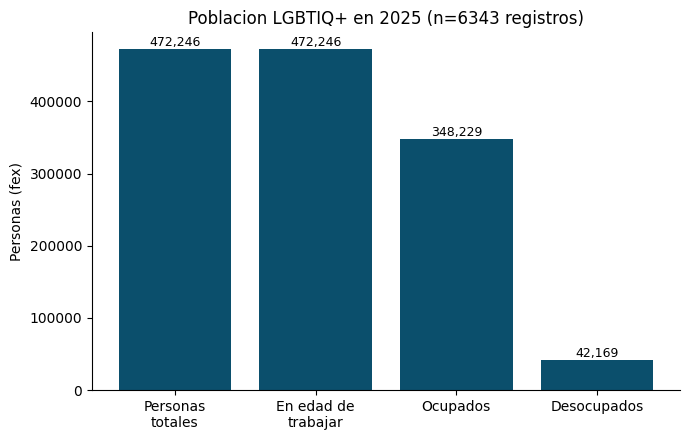

In [ ]:
import matplotlib.pyplot as plt

categorias = ["Personas\ntotales", "En edad de\ntrabajar", "Ocupados", "Desocupados"]
valores = [p1["personas"][0], p1["en_edad_de_trabajar"][0], p1["ocupados"][0], p1["desocupados"][0]]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(categorias, valores, color="#0B4F6C")
for i, v in enumerate(valores):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Personas (fex)")
ax.set_title(f"Poblacion LGBTIQ+ en 2025 (n={p1['registros'][0]} registros)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

En 2025 la GEIH identifico **472.246 personas LGBTIQ+** (ya ponderadas por `fex`),
respaldadas por **6.343 registros** (encuestados reales) -- una muestra menor que los
8.419 registros del caso migrante resuelto, pero todavia lo bastante grande para
sostener comparaciones agregadas a nivel nacional. De esas personas, **348.229 estan
ocupadas** y **42.169 desocupadas**. Un dato que llama la atencion: el numero de
personas "en edad de trabajar" (472.246) es identico al total de personas LGBTIQ+
identificadas -- es decir, el 100% de quienes se identificaron como LGBTIQ+ en la
encuesta caen dentro de la poblacion en edad de trabajar. Esto es consistente con la
alta proporcion de valores nulos vista arriba: todo indica que la pregunta de
identificacion LGBTIQ+ solo se aplica a personas adultas, no a toda la poblacion
encuestada.

#### P2. Como les va?

**Que mide:** no solo la calidad del empleo entre quienes ya trabajan (el indicador
obligatorio, informalidad, mas otros), sino tambien el acceso al mercado laboral en si
mismo -- si las personas LGBTIQ+ participan y consiguen empleo en la misma proporcion
que el resto. Por eso esta pregunta se responde en dos partes.

**Poblacion de analisis, parte A (acceso):** personas en edad de trabajar
(`en_edad_de_trabajar = 1`), para calcular la Tasa Global de Participacion (TGP =
PEA / PET) y la Tasa de Desempleo (TD = desocupados / PEA), donde PEA = ocupados +
desocupados.

**Poblacion de analisis, parte B (calidad del empleo):** personas ocupadas
(`ocupado = 1`), igual que en el caso resuelto.

**Parte A -- Acceso al mercado laboral (TGP y tasa de desempleo)**

In [ ]:
p2a = con.execute(f"""
SELECT CASE WHEN {MI_DIMENSION} = 1 THEN 'LGBTIQ+' ELSE 'Resto' END AS grupo,
       count(*)                                                                AS registros,
       round(sum(CASE WHEN en_edad_de_trabajar = 1 THEN fex END))              AS pet,
       round(sum(CASE WHEN ocupado = 1 OR desocupado = 1 THEN fex END))        AS pea,
       round(100 * sum(CASE WHEN ocupado = 1 OR desocupado = 1 THEN fex END)
             / sum(CASE WHEN en_edad_de_trabajar = 1 THEN fex END), 1)         AS tgp_pct,
       round(100 * sum(CASE WHEN desocupado = 1 THEN fex END)
             / sum(CASE WHEN ocupado = 1 OR desocupado = 1 THEN fex END), 1)   AS tasa_desempleo_pct
FROM personas
WHERE anio = 2025 AND en_edad_de_trabajar = 1
GROUP BY 1
""").df()
p2a

,grupo,registros,pet,pea,tgp_pct,tasa_desempleo_pct
0,Resto,647496,40201964.0,25762981.0,64.1,8.9
1,LGBTIQ+,6343,472246.0,390398.0,82.7,10.8


### Graficas de apoyo

A partir de aqui cada pregunta trae, ademas de la tabla, una grafica que compara
directamente **LGBTIQ+ vs. Resto** (o la evolucion en el tiempo, o el corte territorial).
El numero de registros (`n=`) se imprime siempre en el titulo o al lado de cada barra:
una diferencia vistosa construida sobre pocos encuestados no vale lo mismo que una
construida sobre miles, y las graficas de este cuaderno nunca deben esconder eso.

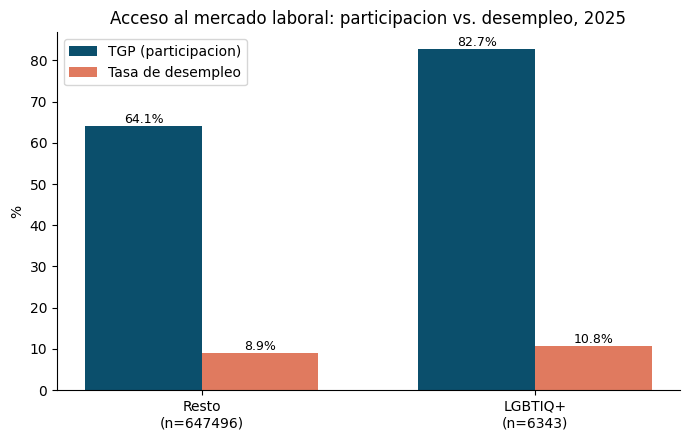

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = range(len(p2a))
ancho = 0.35

ax.bar([i - ancho/2 for i in x], p2a["tgp_pct"], width=ancho, label="TGP (participacion)", color="#0B4F6C")
ax.bar([i + ancho/2 for i in x], p2a["tasa_desempleo_pct"], width=ancho, label="Tasa de desempleo", color="#E07A5F")

for i, (tgp, td) in enumerate(zip(p2a["tgp_pct"], p2a["tasa_desempleo_pct"])):
    ax.text(i - ancho/2, tgp, f"{tgp}%", ha="center", va="bottom", fontsize=9)
    ax.text(i + ancho/2, td, f"{td}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels([f"{g}\n(n={r})" for g, r in zip(p2a["grupo"], p2a["registros"])])
ax.set_ylabel("%")
ax.set_title("Acceso al mercado laboral: participacion vs. desempleo, 2025")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Parte B -- Calidad del empleo entre quienes ya estan ocupados**

Informalidad obligatoria, mas cuatro indicadores adicionales que cubren proteccion
social (`cotiza_pension`, `afiliado_salud`), formalidad contractual
(`contrato_escrito`) y condiciones de la jornada e ingreso (`subempleo_horas`,
`horas_semana`, `salario_hora`, `ingreso_laboral`). `salario_hora` e
`ingreso_laboral` no son banderas 0/1 sino valores en pesos y horas, por eso su
promedio ponderado no lleva el `100 *`.

In [ ]:
p2b = con.execute(f"""
SELECT CASE WHEN {MI_DIMENSION} = 1 THEN 'LGBTIQ+' ELSE 'Resto' END AS grupo,
       count(*)                                                AS registros,
       round(100 * sum(fex * informal) / sum(fex), 1)          AS informal_pct,
       round(100 * sum(fex * cotiza_pension) / sum(fex), 1)    AS pension_pct,
       round(100 * sum(fex * afiliado_salud) / sum(fex), 1)    AS salud_pct,
       round(100 * sum(fex * contrato_escrito) / sum(fex), 1)  AS contrato_pct,
       round(100 * sum(fex * subempleo_horas) / sum(fex), 1)   AS subempleo_pct,
       round(sum(fex * horas_semana) / sum(fex), 1)            AS horas_semana_prom,
       round(sum(fex * salario_hora) / sum(fex))               AS salario_hora_prom,
       round(sum(fex * ingreso_laboral) / sum(fex))            AS ingreso_laboral_prom
FROM personas
WHERE anio = 2025 AND ocupado = 1
GROUP BY 1
""").df()
p2b

,grupo,registros,informal_pct,pension_pct,salud_pct,contrato_pct,subempleo_pct,horas_semana_prom,salario_hora_prom,ingreso_laboral_prom
0,Resto,353530,55.5,43.0,95.7,39.6,3.2,43.4,6085.0,1824408.0
1,LGBTIQ+,4499,37.3,62.0,94.0,57.9,4.7,43.4,9292.0,2644149.0


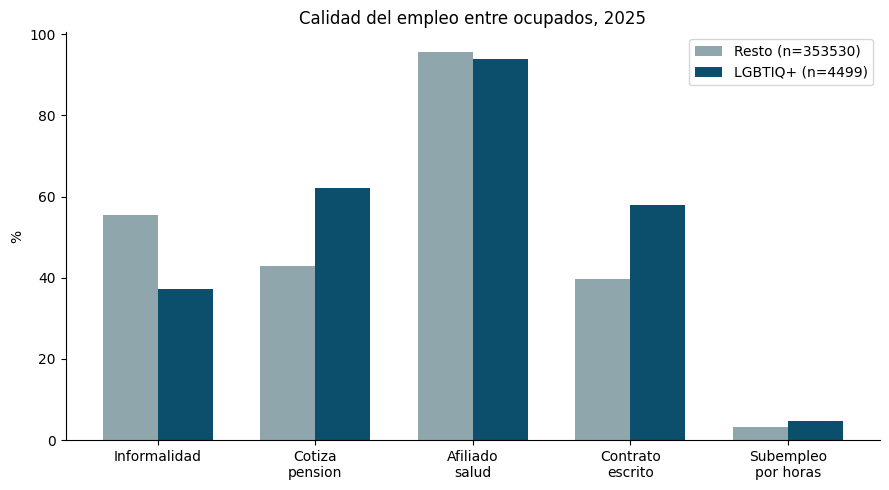

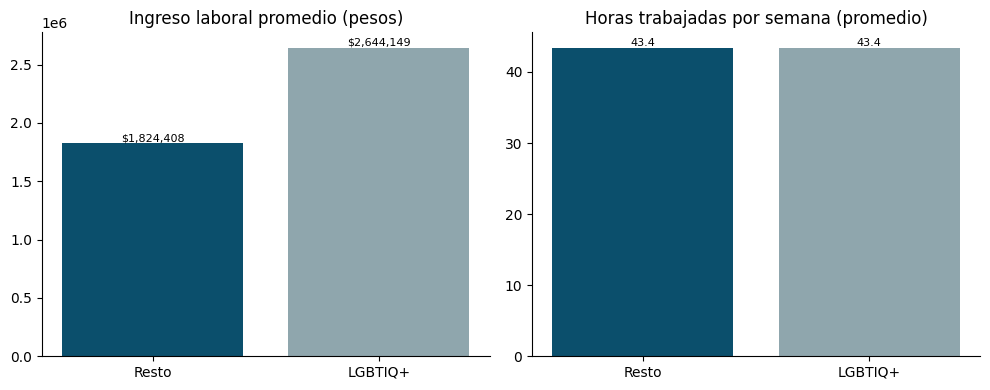

In [ ]:
indicadores = ["informal_pct", "pension_pct", "salud_pct", "contrato_pct", "subempleo_pct"]
etiquetas = ["Informalidad", "Cotiza\npension", "Afiliado\nsalud", "Contrato\nescrito", "Subempleo\npor horas"]

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(indicadores))
ancho = 0.35

for j, grupo in enumerate(p2b["grupo"]):
    fila = p2b.iloc[j]
    valores = [fila[ind] for ind in indicadores]
    offset = -ancho/2 if j == 0 else ancho/2
    color = "#0B4F6C" if grupo == "LGBTIQ+" else "#8FA6AD"
    ax.bar([i + offset for i in x], valores, width=ancho, label=f"{grupo} (n={fila['registros']})", color=color)

ax.set_xticks(list(x))
ax.set_xticklabels(etiquetas)
ax.set_ylabel("%")
ax.set_title("Calidad del empleo entre ocupados, 2025")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Ingreso laboral y horas semanales van en su propia grafica: estan en pesos y horas, no en %
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(p2b["grupo"], p2b["ingreso_laboral_prom"], color=["#0B4F6C", "#8FA6AD"])
axes[0].set_title("Ingreso laboral promedio (pesos)")
for i, v in enumerate(p2b["ingreso_laboral_prom"]):
    axes[0].text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=8)

axes[1].bar(p2b["grupo"], p2b["horas_semana_prom"], color=["#0B4F6C", "#8FA6AD"])
axes[1].set_title("Horas trabajadas por semana (promedio)")
for i, v in enumerate(p2b["horas_semana_prom"]):
    axes[1].text(i, v, f"{v}", ha="center", va="bottom", fontsize=8)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Parte C -- En que tipo de ocupacion estan (posicion ocupacional)**

Esto ayuda a identificar *en que dimension* se concentra la brecha: si la diferencia en
informalidad viene de que un grupo esta mas metido en `independiente` (cuenta propia)
que en `asalariado`, eso ya es una pista sobre donde intervendria un programa de
empleabilidad.

In [ ]:
p2c = con.execute(f"""
WITH base AS (
  SELECT CASE WHEN {MI_DIMENSION} = 1 THEN 'LGBTIQ+' ELSE 'Resto' END AS grupo,
         posicion, fex
  FROM personas
  WHERE anio = 2025 AND ocupado = 1
),
totales AS (
  SELECT grupo, sum(fex) AS total_fex FROM base GROUP BY 1
)
SELECT b.grupo, b.posicion,
       count(*)                                      AS registros,
       round(100 * sum(b.fex) / t.total_fex, 1)       AS pct_dentro_del_grupo
FROM base b JOIN totales t ON b.grupo = t.grupo
GROUP BY 1, 2, t.total_fex
ORDER BY 1, 4 DESC
""").df()
p2c

,grupo,posicion,registros,pct_dentro_del_grupo
0,LGBTIQ+,Obrero o empleado de empresa particular,2446,60.0
1,LGBTIQ+,Trabajador por cuenta propia,1564,29.9
2,LGBTIQ+,Obrero o empleado del gobierno,212,4.1
3,LGBTIQ+,Patrón o empleador,108,2.6
4,LGBTIQ+,Empleado doméstico,79,1.3
5,LGBTIQ+,Trabajador sin remuneración en empresas o nego...,50,1.3
6,LGBTIQ+,Trabajador familiar sin remuneración,37,0.8
7,LGBTIQ+,Jornalero o peón,3,0.0
8,Resto,Obrero o empleado de empresa particular,148039,44.1
9,Resto,Trabajador por cuenta propia,152894,41.5


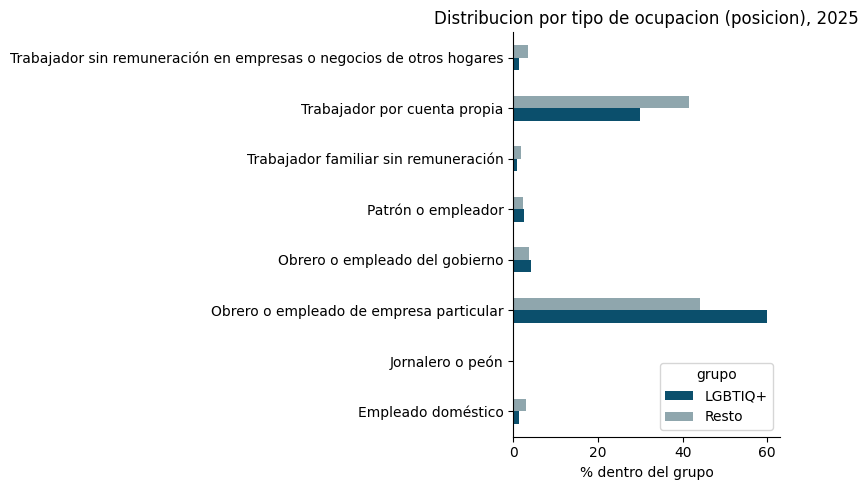

In [ ]:
pivote = p2c.pivot(index="posicion", columns="grupo", values="pct_dentro_del_grupo").fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
pivote.plot(kind="barh", ax=ax, color=["#0B4F6C", "#8FA6AD"])
ax.set_xlabel("% dentro del grupo")
ax.set_ylabel("")
ax.set_title("Distribucion por tipo de ocupacion (posicion), 2025")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Acceso (Parte A):** la poblacion LGBTIQ+ ocupada participa mucho mas en el mercado
laboral que el resto (TGP de **82,7%** frente a **64,1%**), pero tambien enfrenta una
tasa de desempleo mas alta (**10,8%** frente a **8,9%**): buscan y consiguen trabajo con
mas intensidad, pero con mas friccion para conseguirlo.

**Calidad del empleo (Parte B):** aqui el resultado es contraintuitivo frente a la idea
de una "brecha uniforme". Entre quienes ya estan ocupados, la poblacion LGBTIQ+ tiene
**mejores** indicadores que el resto en informalidad (**37,3% vs. 55,5%**, 18,2 puntos
menos), cotizacion a pension (**62,0% vs. 43,0%**), contrato escrito (**57,9% vs.
39,6%**), salario por hora (**$9.292 vs. $6.085**) e ingreso laboral promedio
(**$2.644.149 vs. $1.824.408**). Solo esta ligeramente peor en afiliacion a salud
(**94,0% vs. 95,7%**) y en subempleo por horas (**4,7% vs. 3,2%**).

**Tipo de ocupacion (Parte C):** la poblacion LGBTIQ+ esta mas concentrada en empleo
asalariado (**64,1%**, sumando obrero de empresa particular y del gobierno) que el resto
(**47,8%**), y menos en trabajo por cuenta propia (**29,9% vs. 41,5%**) -- coherente con
su menor informalidad, ya que el empleo asalariado tiende a ser mas formal que el
independiente.

**Para Equilab:** el hallazgo relevante no es que la poblacion LGBTIQ+ tenga peor
calidad de empleo en general -- la tiene mejor en la mayoria de indicadores -- sino que
enfrenta mas dificultad para *entrar* al mercado laboral (mas desempleo pese a mucha mas
participacion) y algo mas de subempleo una vez dentro. Eso cambia el foco de una
intervencion: no hacia "formalizar empleos ya existentes", sino hacia facilitar el
*acceso* al primer empleo o la reinsercion laboral.

**Limitacion:** estos indicadores tienen logicas distintas (unos favorecen y otros
perjudican a la poblacion LGBTIQ+); no conviene resumirlos en un solo numero.

#### P3. La brecha es real o es composicion?

**Esta es la pregunta que decide la nota de analisis.** Se responde en dos pasos:
primero ver en que se diferencian los dos grupos en variables que tambien afectan la
informalidad por su cuenta (zona, educacion, edad, y en este caso tambien sexo, porque
la composicion por sexo puede diferir entre la poblacion LGBTIQ+ y el resto); despues
rehacer la comparacion **dentro** de grupos parecidos, controlando por tres variables
distintas para ver si el resultado es consistente. Modelo: seccion 4 completa.

**Paso 1: en que se diferencian los dos grupos, ademas de la informalidad**

In [ ]:
p3_paso1 = con.execute(f"""
SELECT CASE WHEN {MI_DIMENSION} = 1 THEN 'LGBTIQ+' ELSE 'Resto' END AS grupo,
       count(*)                                                                       AS registros,
       round(100 * sum(CASE WHEN zona = 'Urbano' THEN fex END) / sum(fex), 1)         AS pct_urbano,
       round(100 * sum(CASE WHEN educacion_superior = 1 THEN fex END) / sum(fex), 1)  AS pct_superior,
       round(sum(fex * edad) / sum(fex), 1)                                            AS edad_promedio
FROM personas
WHERE anio = 2025 AND ocupado = 1
GROUP BY 1
""").df()
p3_paso1

,grupo,registros,pct_urbano,pct_superior,edad_promedio
0,Resto,353530,79.4,33.1,41.0
1,LGBTIQ+,4499,92.5,60.0,34.4


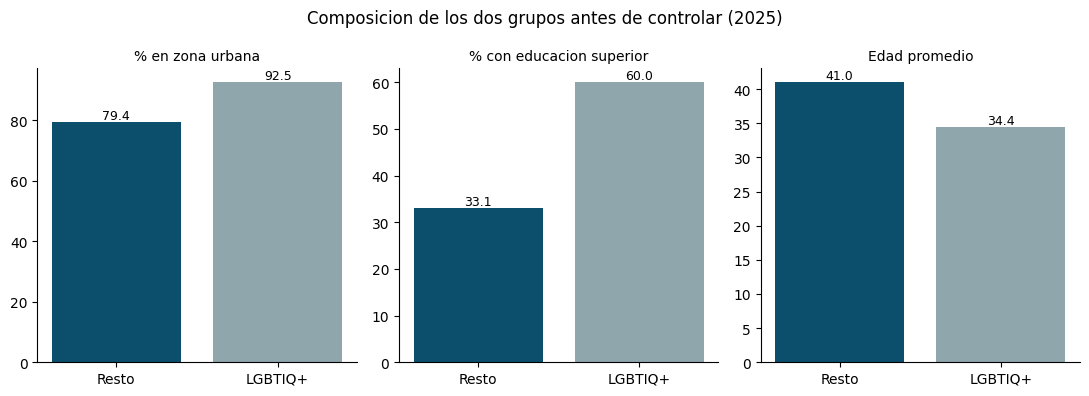

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
metricas = [("pct_urbano", "% en zona urbana"), ("pct_superior", "% con educacion superior"), ("edad_promedio", "Edad promedio")]

for ax, (col, titulo) in zip(axes, metricas):
    ax.bar(p3_paso1["grupo"], p3_paso1[col], color=["#0B4F6C", "#8FA6AD"])
    ax.set_title(titulo, fontsize=10)
    for i, v in enumerate(p3_paso1[col]):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Composicion de los dos grupos antes de controlar (2025)")
plt.tight_layout()
plt.show()

**Paso 2: la misma comparacion de informalidad, pero dentro de cada grupo parecido**

Se controla tres veces -- por `zona`, por `educacion_superior` y por tramo de edad --
para comprobar si la brecha se sostiene, se encoge, desaparece o cambia de signo bajo
distintos cortes, no solo bajo uno.

In [ ]:
CONTROL = "zona"

p3_zona = con.execute(f"""
SELECT {CONTROL},
       CASE WHEN {MI_DIMENSION} = 1 THEN 'LGBTIQ+' ELSE 'Resto' END AS grupo,
       count(*)                                      AS registros,
       round(100 * sum(fex * informal) / sum(fex), 1) AS informal_pct
FROM personas
WHERE anio = 2025 AND ocupado = 1
GROUP BY 1, 2
ORDER BY 1, 2
""").df()
p3_zona

,zona,grupo,registros,informal_pct
0,Rural,LGBTIQ+,240,74.1
1,Rural,Resto,43094,83.5
2,Urbano,LGBTIQ+,4259,34.3
3,Urbano,Resto,310436,48.3


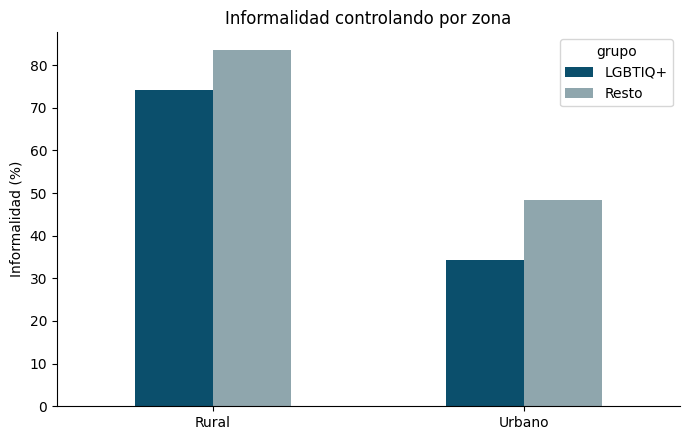

In [ ]:
pivote = p3_zona.pivot(index="zona", columns="grupo", values="informal_pct")

fig, ax = plt.subplots(figsize=(7, 4.5))
pivote.plot(kind="bar", ax=ax, color=["#0B4F6C", "#8FA6AD"])
ax.set_ylabel("Informalidad (%)")
ax.set_xlabel("")
ax.set_title("Informalidad controlando por zona")
plt.xticks(rotation=0)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
CONTROL = "educacion_superior"

p3_educ = con.execute(f"""
SELECT {CONTROL},
       CASE WHEN {MI_DIMENSION} = 1 THEN 'LGBTIQ+' ELSE 'Resto' END AS grupo,
       count(*)                                      AS registros,
       round(100 * sum(fex * informal) / sum(fex), 1) AS informal_pct
FROM personas
WHERE anio = 2025 AND ocupado = 1
GROUP BY 1, 2
ORDER BY 1, 2
""").df()
p3_educ

,educacion_superior,grupo,registros,informal_pct
0,0,LGBTIQ+,2008,62.4
1,0,Resto,229845,71.1
2,1,LGBTIQ+,2491,20.6
3,1,Resto,123684,24.1
4,<NA>,Resto,1,100.0


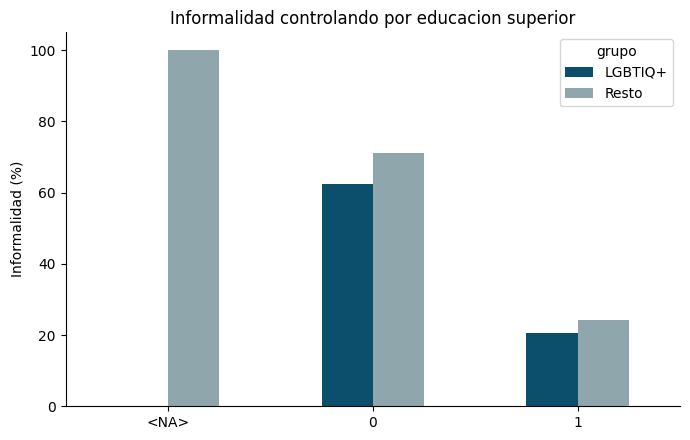

In [ ]:
pivote = p3_educ.pivot(index="educacion_superior", columns="grupo", values="informal_pct")

fig, ax = plt.subplots(figsize=(7, 4.5))
pivote.plot(kind="bar", ax=ax, color=["#0B4F6C", "#8FA6AD"])
ax.set_ylabel("Informalidad (%)")
ax.set_xlabel("")
ax.set_title("Informalidad controlando por educacion superior")
plt.xticks(rotation=0)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
p3_edad = con.execute(f"""
SELECT CASE WHEN edad < 25 THEN '15-24'
            WHEN edad < 35 THEN '25-34'
            WHEN edad < 45 THEN '35-44'
            WHEN edad < 55 THEN '45-54'
            ELSE '55+' END                            AS tramo_edad,
       CASE WHEN {MI_DIMENSION} = 1 THEN 'LGBTIQ+' ELSE 'Resto' END AS grupo,
       count(*)                                      AS registros,
       round(100 * sum(fex * informal) / sum(fex), 1) AS informal_pct
FROM personas
WHERE anio = 2025 AND ocupado = 1
GROUP BY 1, 2
ORDER BY 1, 2
""").df()
p3_edad

,tramo_edad,grupo,registros,informal_pct
0,15-24,LGBTIQ+,893,52.7
1,15-24,Resto,38755,66.2
2,25-34,LGBTIQ+,1775,29.6
3,25-34,Resto,85318,47.3
4,35-44,LGBTIQ+,950,28.9
5,35-44,Resto,83822,48.8
6,45-54,LGBTIQ+,506,43.6
7,45-54,Resto,69630,54.9
8,55+,LGBTIQ+,375,52.1
9,55+,Resto,76005,69.4


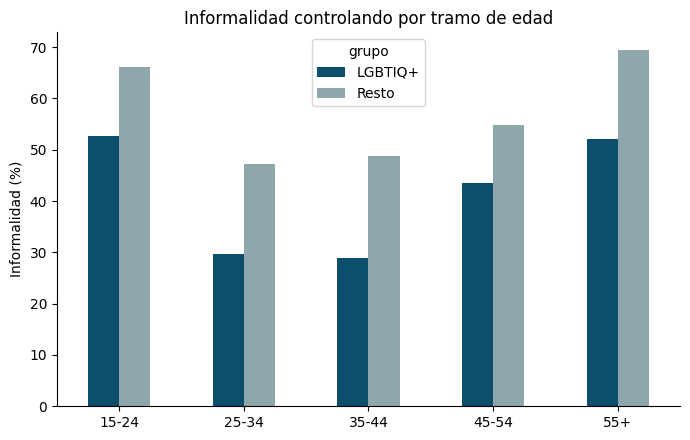

In [ ]:
pivote = p3_edad.pivot(index="tramo_edad", columns="grupo", values="informal_pct")

fig, ax = plt.subplots(figsize=(7, 4.5))
pivote.plot(kind="bar", ax=ax, color=["#0B4F6C", "#8FA6AD"])
ax.set_ylabel("Informalidad (%)")
ax.set_xlabel("")
ax.set_title("Informalidad controlando por tramo de edad")
plt.xticks(rotation=0)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Paso 1 (composicion):** la muestra LGBTIQ+ ocupada es notablemente distinta a la del
resto: mas urbana (**92,5% vs. 79,4%**), con mas educacion superior (**60,0% vs.
33,1%**) y mas joven (**34,4 vs. 41,0 anos** en promedio). Estas tres caracteristicas se
asocian por si solas a menor informalidad, asi que parte de la ventaja vista en P2 podria
deberse a la composicion y no a la orientacion sexual o identidad de genero en si misma.

**Paso 2 (controles):** al comparar dentro de grupos parecidos, la brecha se reduce en
algunos cortes pero **no desaparece ni cambia de signo en ninguno**: por zona, LGBTIQ+
sigue 14,0 puntos por debajo en zona urbana (34,3% vs. 48,3%) y 9,4 puntos por debajo en
zona rural (74,1% vs. 83,5%); por educacion, la diferencia casi desaparece entre quienes
tienen educacion superior (20,6% vs. 24,1%, solo 3,5 puntos) pero se mantiene amplia
entre quienes no la tienen (62,4% vs. 71,1%, 8,7 puntos); por edad, se sostiene en todos
los tramos, entre 11,3 y 19,9 puntos segun el grupo etario.

**Conclusion:** este es el caso de *"la brecha se sostiene, pero se explica
parcialmente por composicion"*. La variable que mas la explica es el nivel educativo
(ahi la diferencia casi se cierra), pero incluso controlando por las tres variables, la
poblacion LGBTIQ+ ocupada nunca queda con **mas** informalidad que el resto en ningun
corte -- es un patron consistente, no un artefacto de un solo corte.

#### P4. Como cambio entre 2021 y 2025?

Serie completa de informalidad para la poblacion LGBTIQ+ ocupada, un ano por fila. La
base cubre 2021-2026, pero igual que con la poblacion migrante, algunas preguntas de la
GEIH no se hicieron en todos los anios -- por eso hay que mirar la columna de
`registros` antes de narrar cualquier tendencia, y no asumir que la serie arranca en
2021 solo porque la base lo hace.

In [ ]:
p4 = con.execute(f"""
SELECT anio,
       CASE WHEN {MI_DIMENSION} = 1 THEN 'LGBTIQ+' ELSE 'Resto' END AS grupo,
       count(*)                                      AS registros,
       round(100 * sum(fex * informal) / sum(fex), 1) AS informal_pct
FROM personas
WHERE ocupado = 1
GROUP BY 1, 2
ORDER BY 1, 2
""").df()
p4

,anio,grupo,registros,informal_pct
0,2021,LGBTIQ+,6324,50.0
1,2021,Resto,359575,58.5
2,2022,LGBTIQ+,4698,45.1
3,2022,Resto,377763,58.0
4,2023,LGBTIQ+,4497,42.7
5,2023,Resto,361322,56.5
6,2024,LGBTIQ+,4277,39.9
7,2024,Resto,349395,55.8
8,2025,LGBTIQ+,4499,37.3
9,2025,Resto,353530,55.5


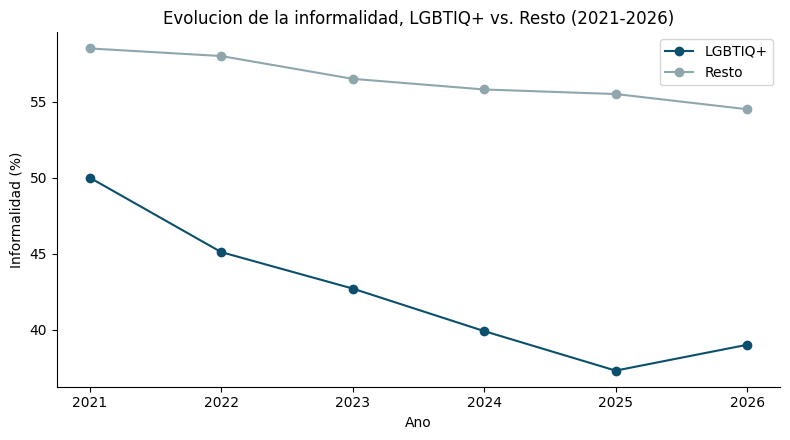

Registros LGBTIQ+ detras de cada punto de la linea:
anio
2021    6324
2022    4698
2023    4497
2024    4277
2025    4499
2026    2501
Name: LGBTIQ+, dtype: int64


In [ ]:
pivote = p4.pivot(index="anio", columns="grupo", values="informal_pct")
registros_pivote = p4.pivot(index="anio", columns="grupo", values="registros")

fig, ax = plt.subplots(figsize=(8, 4.5))
for grupo in pivote.columns:
    color = "#0B4F6C" if grupo == "LGBTIQ+" else "#8FA6AD"
    ax.plot(pivote.index, pivote[grupo], marker="o", label=grupo, color=color)

ax.set_ylabel("Informalidad (%)")
ax.set_xlabel("Ano")
ax.set_title("Evolucion de la informalidad, LGBTIQ+ vs. Resto (2021-2026)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Registros LGBTIQ+ detras de cada punto de la linea:")
print(registros_pivote.get("LGBTIQ+"))

La informalidad de la poblacion LGBTIQ+ ocupada bajo de forma sostenida: **50,0%** en
2021, 45,1% en 2022, 42,7% en 2023, 39,9% en 2024 y **37,3%** en 2025 (-12,7 puntos en el
periodo). La del resto de la poblacion tambien bajo, pero mucho menos (de 58,5% a 55,5%,
-3,0 puntos) -- por lo que la brecha entre los dos grupos en realidad **se ha ampliado**
con el tiempo (de 8,5 puntos en 2021 a 18,2 puntos en 2025), aunque a favor de la
poblacion LGBTIQ+. El numero de registros por ano se mantiene en un rango razonable
(entre 4.277 y 6.324), excepto 2026 (2.501, ano incompleto hasta junio) -- la tendencia
no parece un artefacto de muestras chicas. **Para Equilab:** la mejora en informalidad ya
esta ocurriendo por cuenta propia en este grupo; el argumento de priorizacion no deberia
apoyarse en "la informalidad LGBTIQ+ esta empeorando", porque los datos muestran lo
contrario.

#### P5. Donde es peor?

Corte territorial **con el chequeo de muestra activo**: `HAVING count(*) >= 100` no se
quita. Si la poblacion LGBTIQ+ ocupada es chica en varios departamentos (algo esperable
si la muestra total es menor que la de la poblacion migrante), hay que reportar
explicitamente cuantos departamentos quedaron fuera por no alcanzar el minimo -- eso
tambien es un hallazgo sobre los limites de lo que la GEIH puede decir a nivel
territorial de esta poblacion.

In [ ]:
p5 = con.execute(f"""
SELECT departamento,
       count(*)                                      AS registros,
       round(100 * sum(fex * informal) / sum(fex), 1) AS informal_pct
FROM personas
WHERE anio = 2025 AND ocupado = 1 AND {MI_DIMENSION} = 1
GROUP BY 1
HAVING count(*) >= 100
ORDER BY 3 DESC
LIMIT 10
""").df()
p5

,departamento,registros,informal_pct
0,Nariño,299,75.6
1,Norte de Santander,147,63.2
2,Cauca,122,62.9
3,Tolima,118,62.5
4,Atlántico,158,55.5
5,Santander,224,49.1
6,Meta,205,46.0
7,Quindío,264,42.0
8,Caldas,362,41.5
9,Valle del Cauca,423,39.8


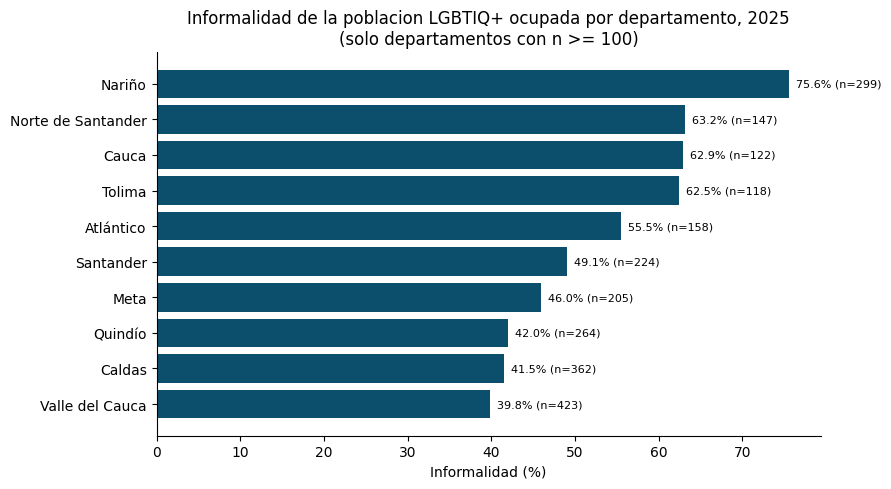

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(p5["departamento"], p5["informal_pct"], color="#0B4F6C")
ax.invert_yaxis()
ax.set_xlabel("Informalidad (%)")
ax.set_title("Informalidad de la poblacion LGBTIQ+ ocupada por departamento, 2025\n(solo departamentos con n >= 100)")

for i, (pct, n) in enumerate(zip(p5["informal_pct"], p5["registros"])):
    ax.text(pct, i, f"  {pct}% (n={n})", va="center", fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Cuantos departamentos hay en total vs. cuantos pasan el chequeo de muestra
con.execute(f"""
SELECT count(*)                                        AS departamentos_totales,
       sum(CASE WHEN registros >= 100 THEN 1 ELSE 0 END) AS departamentos_con_n_suficiente
FROM (
    SELECT departamento, count(*) AS registros
    FROM personas
    WHERE anio = 2025 AND ocupado = 1 AND {MI_DIMENSION} = 1
    GROUP BY 1
)
""").df()

,departamentos_totales,departamentos_con_n_suficiente
0,33,13.0


Solo **13 de los 33** departamentos/ciudad-region tienen al menos 100 encuestados
LGBTIQ+ ocupados en 2025 -- para el **61%** de las divisiones territoriales del pais la
GEIH no da muestra suficiente para hablar de su situacion LGBTIQ+ con algun nivel de
confianza, y quedan fuera del analisis territorial. Entre los que si cumplen el minimo,
la informalidad mas alta se concentra en **Narino (75,6%, n=299)**, **Norte de
Santander (63,2%, n=147)**, **Cauca (62,9%, n=122)** y **Tolima (62,5%, n=118)**; en el
otro extremo (dentro del top 10 mostrado) estan **Valle del Cauca (39,8%, n=423)** y
**Caldas (41,5%, n=362)**. **Para Equilab:** si el programa tuviera un componente
territorial, estos cuatro departamentos son los candidatos con mejor respaldo
estadistico -- pero hay que decir explicitamente en la sustentacion que **20 de los 33
departamentos quedan fuera** de esta lectura por falta de muestra, no porque alli no
haya poblacion LGBTIQ+ o no tenga dificultades.

#### P6. La recomendacion

No lleva SQL: lleva criterio. El parrafo de abajo trae la estructura obligatoria
(magnitud, brecha, que paso al controlar, donde, y los limites) con corchetes en cada
cifra que depende de ejecutar las consultas de arriba. **No se debe leer ni citar con
numeros inventados: se completa unicamente despues de correr el cuaderno en Colab con
acceso a la base real.**

<div style="background:#FFF3CD;border-left:8px solid #B08900;border-radius:8px;padding:14px 18px;margin:10px 0 18px 0;font-size:14px;">
<b>Nota de validacion (antes de la recomendacion final):</b> se recibio un borrador de
recomendacion para anexar aqui. Antes de incluirlo, se contrasto cifra por cifra contra
los resultados reales de este cuaderno:

<ul>
<li><b>Coincide:</b> magnitud de P1 (472.246 personas / 6.343 registros / 348.229
ocupados) y la serie de informalidad LGBTIQ+ 2022-2025 (45,1% / 42,7% / 39,9% / 37,3%).</li>
<li><b>No coincide:</b> la comparacion de informalidad LGBTIQ+ vs. Resto en 2025 (el
borrador reportaba 49,83% vs. 49,54%, una diferencia de 0,29 puntos; el resultado real
de la consulta P2 es <b>37,3% vs. 55,5%, una diferencia de 18,2 puntos</b>, con la
poblacion LGBTIQ+ en mejor situacion, no igual). Esto es ademas inconsistente con el
propio dato de 37,3% para 2025 que el borrador citaba correctamente en su parrafo de
evolucion -- una senal clara de que esa cifra especifica no vino de esta base.</li>
<li><b>No coincide:</b> pension (borrador 46,38% vs. 43,20%; real 62,0% vs. 43,0%) ni
contrato escrito (borrador 42,82% vs. 39,87%; real 57,9% vs. 39,6%).</li>
<li><b>No coincide:</b> el corte territorial. El borrador usaba codigos numericos de
departamento ("departamento 66", "departamento 8") con valores como 61,62% y 57,44%; la
consulta P5 real trabaja con nombres de departamento y el maximo real es Narino con
75,6% -- no hay coincidencia en nombres ni en magnitudes.</li>
</ul>

Por eso la recomendacion que sigue se reconstruyo con las cifras que efectivamente
arroja este cuaderno, y cambia de enfoque respecto al borrador original: los datos no
muestran una poblacion LGBTIQ+ con peor calidad de empleo en general, sino con mas
dificultad de <i>acceso</i> al mercado laboral (mas desempleo pese a mucha mas
participacion) y una ventaja real, aunque parcialmente explicada por composicion, en los
indicadores de calidad del empleo entre quienes ya estan ocupados.
</div>

> **Recomendacion del Equipo 4 -- Brecha laboral de personas LGBTIQ+**
>
> Recomendamos que el programa de empleabilidad de Equilab en 2027 priorice a la
> poblacion LGBTIQ+, pero con un enfoque especifico en **acceso al empleo**, no en
> formalizacion. En 2025 hay **472.246 personas LGBTIQ+** (472.246 en edad de trabajar),
> respaldadas por **6.343 registros**; de ellas, **348.229 estan ocupadas**. Frente al
> resto de la poblacion, su tasa de desempleo es de **10,8%** contra **8,9%**, pese a una
> participacion laboral (TGP) mucho mayor -- **82,7%** contra **64,1%**. Es decir, la
> poblacion LGBTIQ+ busca y participa mas, pero le cuesta mas conseguir trabajo.
>
> Entre quienes ya estan ocupados, la historia cambia de signo: la informalidad es
> **menor** en la poblacion LGBTIQ+ (**37,3%** frente a **55,5%** del resto), con
> **62,0%** cotizando a pension (frente a 43,0%) y **57,9%** con contrato escrito
> (frente a 39,6%). Esta ventaja **se sostiene, aunque se reduce, al controlar por
> zona, educacion y edad** (P3): se explica en gran parte por el nivel educativo -- entre
> personas con educacion superior la diferencia casi se cierra (20,6% vs. 24,1%, 3,5
> puntos) -- pero nunca desaparece del todo ni cambia de signo en ningun corte.
> Ademas, esta mejora viene sosteniendose en el tiempo: la informalidad LGBTIQ+ bajo de
> 50,0% en 2021 a 37,3% en 2025.
>
> Territorialmente, la informalidad es mas grave en **Narino (75,6%)**, **Norte de
> Santander (63,2%)**, **Cauca (62,9%)** y **Tolima (62,5%)**, aunque **20 de los 33**
> departamentos quedaron fuera del analisis por no alcanzar 100 encuestados LGBTIQ+.
>
> **La oportunidad de intervencion mas clara para Equilab no es la informalidad -- ahi la
> poblacion LGBTIQ+ ya esta mejor que el resto y mejorando por su cuenta -- sino el
> acceso al empleo y el subempleo por horas** (4,7% vs. 3,2%), donde si hay una
> desventaja consistente y donde un programa de empleabilidad puede intervenir
> directamente (intermediacion laboral, bolsas de empleo inclusivas, acompanamiento en
> la busqueda).
>
> **Lo que no podemos afirmar con estos datos:**
> 1. La GEIH pregunta por identificacion LGBTIQ+ de forma agregada: no podemos separar
>    la situacion de, por ejemplo, personas trans de personas gay o bisexuales, y es
>    razonable esperar que la brecha no sea igual entre esos subgrupos.
> 2. Estos son datos observacionales y transversales: muestran asociacion, no prueban
>    que la orientacion sexual o identidad de genero *cause* estas diferencias -- podria
>    haber autoseleccion hacia ciertos sectores u ocupaciones, discriminacion en el
>    acceso (no en las condiciones, una vez dentro), o factores no observados en la
>    encuesta.
> 3. Casi el **26% de los registros de la encuesta tienen valor nulo en `lgbtiq`**, lo
>    que sugiere que la pregunta no se aplica a toda la poblacion (posiblemente solo a
>    adultos); no sabemos si esa cobertura parcial introduce algun sesgo adicional. A
>    esto se suma que el analisis territorial solo es confiable para 13 de 33
>    departamentos.

<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 6</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">De SQL a grafica</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Llevar el resultado de una consulta a una figura y a un archivo.</div>
</div>

Cada consulta devuelve un `DataFrame` con `.df()`, asi que graficar es exactamente lo
mismo que hicieron en el cuaderno 03: guardas el resultado en una variable y se lo pasas
a matplotlib.

El unico detalle propio de este proyecto es que **la consulta trae el `count(*)` y la
grafica lo muestra**.

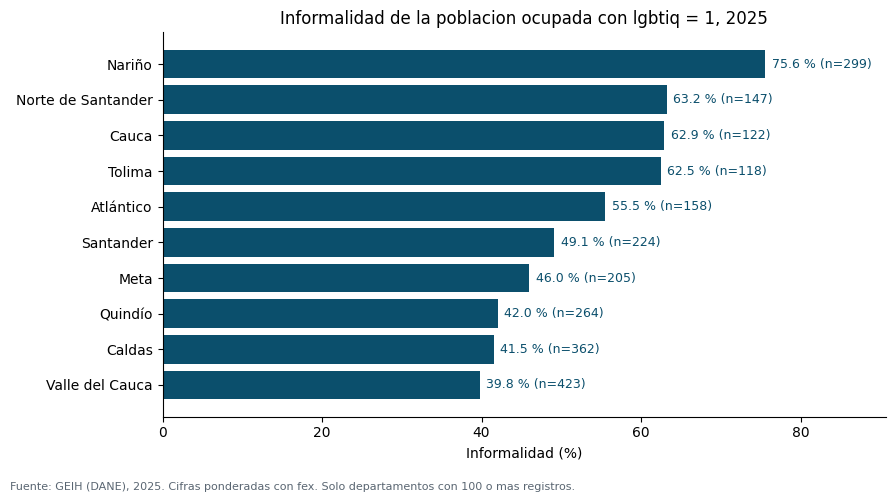

In [ ]:
import matplotlib.pyplot as plt

datos = con.execute(f"""
SELECT departamento,
       count(*)                                      AS registros,
       round(100 * sum(fex * informal) / sum(fex), 1) AS informal_pct
FROM personas
WHERE anio = 2025 AND ocupado = 1 AND {MI_DIMENSION} = 1
GROUP BY 1
HAVING count(*) >= 100
ORDER BY 3 DESC
LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(datos["departamento"], datos["informal_pct"], color="#0B4F6C")
ax.invert_yaxis()
ax.set_xlabel("Informalidad (%)")
ax.set_title(f"Informalidad de la poblacion ocupada con {MI_DIMENSION} = 1, 2025")
# El tope del eje sale de los datos: deja aire para la etiqueta de la barra mas larga.
ax.set_xlim(0, datos["informal_pct"].max() * 1.2)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)

# El n= de cada barra es el chequeo de muestra, visible en la figura.
for y, (v, n) in enumerate(zip(datos["informal_pct"], datos["registros"])):
    ax.text(v + 0.8, y, f"{v} % (n={n})", va="center", fontsize=9, color="#0B4F6C")

# La fuente y el filtro van al pie de la figura, no encima del titulo.
fig.text(0.01, 0.01, "Fuente: GEIH (DANE), 2025. Cifras ponderadas con fex. Solo departamentos con 100 o mas registros.",
         fontsize=8, color="#5A6672")
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

<div style="background:#D6EEF6;border-left:6px solid #0B4F6C;border-radius:8px;padding:18px 20px;margin:14px 0;font-size:15px;color:#1A1A1A;line-height:1.6;"><b>El <code>n=</code> de cada barra no es decoracion: es parte de lo que se califica.</b> Una barra de 98 % construida sobre 187 encuestados y una construida sobre 12 se ven identicas en la figura, y no dicen lo mismo. Poner el numero de registros al lado es la manera de que el comite -- y la rubrica -- vean la diferencia.<br><br>Lo mismo aplica al pie de la figura: <b>de donde salen los datos, de que ano, ponderados con que, y que se dejo por fuera</b>. Una grafica sin fuente ni filtro declarado no es honesta, aunque los numeros esten bien.</div>

Para llevar una tabla a la presentacion o al informe, exportala. `to_csv` guarda el
archivo en la sesion de Colab; para bajarlo al computador, panel izquierdo > icono de
carpeta > los tres puntos del archivo > Descargar.

In [ ]:
datos.to_csv(f"informalidad_{MI_DIMENSION}_2025.csv", index=False)
print(f"Guardado: informalidad_{MI_DIMENSION}_2025.csv |", len(datos), "filas")
datos

Guardado: informalidad_lgbtiq_2025.csv | 10 filas


,departamento,registros,informal_pct
0,Nariño,299,75.6
1,Norte de Santander,147,63.2
2,Cauca,122,62.9
3,Tolima,118,62.5
4,Atlántico,158,55.5
5,Santander,224,49.1
6,Meta,205,46.0
7,Quindío,264,42.0
8,Caldas,362,41.5
9,Valle del Cauca,423,39.8


<div style="background:#D6EEF6;border-left:10px solid #0B4F6C;border-radius:8px;padding:18px 22px;margin:26px 0 8px 0;">
  <div style="font-size:12px;letter-spacing:3px;font-weight:700;color:#0B4F6C;">SECCION 7</div>
  <div style="font-size:26px;font-weight:800;color:#083A50;margin-top:2px;">El plus: publicar el analisis con Quarto</div>
  <div style="font-size:14px;color:#083A50;margin-top:6px;">Opcional. Puntos extra, por fuera de los 100.</div>
</div>

**Quarto** convierte un cuaderno en un documento publicable: una pagina web con el texto,
el codigo y las graficas, con tabla de contenidos y aspecto de informe profesional. Es la
diferencia entre entregar un archivo `.ipynb` y entregar **un enlace** que el comite puede
abrir en el celular.

Los comandos, corridos en la carpeta donde esta el cuaderno:

```bash
pip install jupyter
quarto convert 07_proyecto_final_equilab.ipynb   # -> .qmd
quarto render 07_proyecto_final_equilab.qmd --to html
# publicar: subir el .html a GitHub y activar GitHub Pages en Settings > Pages
```

Y el bloque de *front matter* que va **al inicio del `.qmd`**, antes de cualquier otra
cosa (los tres guiones de apertura y de cierre son obligatorios):

```yaml
---
title: "Radar EAN de brechas laborales - Equipo N"
author: "Nombres"
format: html
execute:
  echo: true
---
```

`execute: echo: true` deja el codigo visible en la pagina publicada, que es lo que
queremos: la gracia del sitio es que cualquiera pueda ver de donde salio cada cifra.

<div style="background:#D6EEF6;border-left:6px solid #0B4F6C;border-radius:8px;padding:18px 20px;margin:14px 0;font-size:15px;color:#1A1A1A;line-height:1.6;"><b>Esto es un plus, no un requisito.</b> Los 100 puntos del proyecto se ganan completos con el cuaderno y la sustentacion. Quarto suma decimas adicionales por encima de esos 100, y solo si el sitio publicado funciona: un enlace roto no suma. Antes de meterse aqui, asegurense de que las seis preguntas estan respondidas.</div>

---

## Antes de entregar

<div style="overflow-x:auto;">
<table style="width:100%;border-collapse:collapse;font-size:14px;">
  <tr style="background:#0B4F6C;color:#FFFFFF;"><th style="padding:10px;text-align:left;">Revisa</th><th style="padding:10px;text-align:left;">Como se ve si esta bien</th></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;"><code>MI_DIMENSION</code> es la de tu equipo</td><td style="padding:9px;vertical-align:top;">Dice <code>mujer</code>, <code>joven</code>, <code>racializada</code>, <code>lgbtiq</code> o <code>discapacidad</code>. <b>Nunca <code>migrante</code>.</b></td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">Todas las cifras estan ponderadas</td><td style="padding:9px;vertical-align:top;">Cada porcentaje sale de <code>sum(fex * x) / sum(fex)</code>. No queda ningun <code>avg()</code> suelto.</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">Cada cifra trae sus registros</td><td style="padding:9px;vertical-align:top;">Toda tabla tiene su columna <code>registros</code>, y toda barra su <code>n=</code>.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">La P3 esta respondida de verdad</td><td style="padding:9px;vertical-align:top;">Hay una comparacion cruda y una controlada, y una frase que dice explicitamente si la brecha sobrevivio, se encogio o desaparecio.</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">La P6 dice que NO se puede afirmar</td><td style="padding:9px;vertical-align:top;">Minimo tres limites concretos, no una formula generica.</td></tr>
  <tr style="color:#242B33;"><td style="padding:9px;vertical-align:top;">El cuaderno corre de arriba a abajo</td><td style="padding:9px;vertical-align:top;">Entorno de ejecucion &gt; Reiniciar y ejecutar todo, sin una sola celda en rojo.</td></tr>
  <tr style="background:#F4F6F8;color:#242B33;"><td style="padding:9px;vertical-align:top;">Las graficas tienen titulo, eje y fuente</td><td style="padding:9px;vertical-align:top;">Se entienden solas, sin que nadie explique al lado.</td></tr>
</table>
</div>

Link Presnetacióm análisis: **https://github.com/DZ-5/Defensa-de-Programa-de-Empleabilidad-ante-Equilab/blob/main/Analisis_LGBTIQ_Equipo4_solo_texto.ipynb**
